![ATARRI logos](img/logos.png)

# 2.4 Vertical profile of dust concentration

#### Objective 

The objective of this notebook is to showcase the construction of a vertical temporal-altitude profile with a set of input coordinates.

## Introduction: Temporal-altitude profiles

These vertical profiles are particularly useful for visualising the evolution of dust variables at specific altitudes through time. In our case, they can be especially helpful at understanding how our dust event might impact a specific location, rather than a whole region or country, as we have seen until now.

We have already noted the impact of the dust event across Cyprus. Hence, with the temporal-altitude sections, we will now look closely at a city, such as Limassol.

To begin, we will load all our libraries and our `functions.ipynb` notebook.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm

import warnings
warnings.filterwarnings('ignore')

In [2]:
from IPython.utils.io import capture_output
with capture_output():
    %run ../functions/functions1.ipynb

## Variable set-up

For this exercise, we will visualise from our file corresponding to `2025-03-05`.

In [3]:
ds = xr.open_dataset('/shared/data/exp_to_interp/monarch/regional/3hourly/sconc_dust/sconc_dust_2025030512.nc', chunks={"time": 1, "lev": 1})
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 29, lev: 14, lat: 825, lon: 1650)
Coordinates:
  * time        (time) datetime64[ns] 232B 2025-03-05T12:00:00 ... 2025-03-09
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
Data variables:
    sconc_dust  (time, lev, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 413, 825), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Wed Mar  5 18:04:20 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Thu Mar  6 11:34:23 2025: ncap2 -O -v -s wher...

Next, we will load our input variables:

- Concentration subset
- Latitude
- Longitude
- Normalisation ranges

In [4]:
sconc = ds['sconc_dust']
lat = 34.667
lon = 33.025

## Subsetting data from our point

We now subset our data at the selected latitude and longitude, after which we make the conversion to µg/m3.

The result is a two-dimensional array with dust concentration across all altitude levels and time steps over Limassol.

In [5]:
point = sconc.sel(lon=lon, lat=lat, method="nearest")
point

<xarray.DataArray 'sconc_dust' (time: 29, lev: 14)> Size: 2kB
dask.array<getitem, shape=(29, 14), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 232B 2025-03-05T12:00:00 ... 2025-03-09
  * lev      (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
    lat      float64 8B 34.65
    lon      float64 8B 33.05
Attributes:
    grid_mapping:  crs
    units:         kgm-3

In [6]:
point = (point * 1e9 * 2).compute()
point

<xarray.DataArray 'sconc_dust' (time: 29, lev: 14)> Size: 2kB
array([[5.09849777e+01, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12],
       [3.30051498e+01, 3.17770138e+01, 2.88898983e+01, 1.77213669e+01,
        1.93614082e+01, 1.38370152e+01, 4.75487518e+01, 7.89792099e+01,
        3.05656967e+01, 1.49147701e+01, 1.00144119e+01, 3.74824572e+00,
        6.11372404e-02, 5.72077177e-08],
       [9.45453644e+00, 1.10365038e+01, 1.64719906e+01, 2.75225105e+01,
        2.74537296e+01, 4.00788879e+01, 4.63573990e+01, 2.92685661e+01,
        1.87587605e+01, 1.42491446e+01, 1.67890854e+01, 9.86807632e+00,
        9.92012620e-02, 2.00410244e-09],
       [2.45850277e+01, 2.41404190e+01, 1.53085575e+01, 2.03354740e+01,
        2.86347923e+01, 6.88877640e+01, 5.82826233e+01, 2.50622253e+01,
        1.51005783e+01, 1.61872444e+01, 8.27835083e+00, 6.67915821e+00,
        1.03733075e+00, 2.60869086e-08],
       [1.96542187e+01, 1.63393135e+01, 1.64322624e+01, 9.68665695e+01,
        1.53973709e+02, 1.67751495e+02, 1.37665268e+02, 7.18391724e+01,
        5.26111298e+01, 2.01414127e+01, 3.62146282e+00, 6.52979326e+00,
        5.84574938e-01, 1.52668036e-07],
...
       [4.01180191e+01, 5.25651741e+01, 6.14334106e+01, 7.37828140e+01,
        8.41408539e+01, 1.06600014e+02, 1.44534286e+02, 8.35015488e+01,
        3.29676056e+01, 1.97374592e+01, 5.95533228e+00, 2.25001168e+00,
        4.86777388e-02, 1.15719056e-04],
       [3.18810902e+01, 4.22672005e+01, 6.18999481e+01, 8.52214737e+01,
        1.12405823e+02, 1.75842728e+02, 1.40387344e+02, 8.90111542e+01,
        3.81747131e+01, 1.66329823e+01, 5.54805374e+00, 1.64462686e+00,
        2.70757154e-02, 1.55492864e-06],
       [2.28771324e+01, 2.48207531e+01, 4.45995636e+01, 6.83175201e+01,
        8.84126434e+01, 1.24619606e+02, 1.25604500e+02, 9.30269547e+01,
        3.61359749e+01, 1.50735407e+01, 5.05613661e+00, 8.10116708e-01,
        1.81293581e-02, 9.01162480e-07],
       [4.12010002e+00, 7.17391253e+00, 2.26943798e+01, 4.71442261e+01,
        8.23655243e+01, 1.45181213e+02, 1.17707985e+02, 9.04062500e+01,
        3.47175522e+01, 1.51939898e+01, 5.14091015e+00, 1.04409146e+00,
        9.84990690e-03, 2.19232334e-06],
       [3.38734341e+00, 6.74841881e+00, 1.46317387e+01, 2.79548168e+01,
        3.88848801e+01, 1.10184052e+02, 1.30735077e+02, 8.93974075e+01,
        4.55141945e+01, 1.70147915e+01, 4.34749699e+00, 1.38769388e+00,
        7.24919839e-03, 1.73397200e-06]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 232B 2025-03-05T12:00:00 ... 2025-03-09
  * lev      (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
    lat      float64 8B 34.65
    lon      float64 8B 33.05

## Plotting

Since we are not plotting over a map, we do not need to use our `cartopy` features. Instead, we will create our 2D plot using `contourf`.  For this, we need to prepare:

- `time`: variable with our time values for the x-axis, converted with `to_datetime`.
- `lev`: variable with our altitude values for the y-axis.
- `point`: our concentration data at our selected point, transposed so that our axes are displayed accordingly.

In [7]:
time = pd.to_datetime(point['time'].values)
lev = point['lev'].values 

Next, we will construct our plotting structure. In our previous exercises, we used `pcolormesh` and, due to the amount of lat/lon coordinate sets, our map had the appearance of a contour map. However, in this vertical profile we will apply `contourf`, which will take our data points and create interpolated contour lines. For this to work, we will need to have the following additional inputs:

- `levels`: parameter to define the boundaries between contoured colors. When plotting with `contourf`, this needs to be set explicitly.
- `cmap`: colourmap of our plot (we will use our custom function to set the BDRC `cmap`).
- `norm`: applies normalisation to our data variable values (i.e. groups our values into ranges for the display).
- `extend`: parameter to set the lower limit of the maximum range in the colorbar. When plotting with `contourf`, this needs to be set explicitly.

In [8]:
cmap_bdrc = get_cmap_bdrc()
concdu_norm = get_normalised_bdrc("sconc_dust", cmap_bdrc)

Since we need to explicitly set `levels` to our BDRC boundaries, we can return the intervals from our `norm` object. For this, we can use `BoundaryNorm.boundaries`. If you print it, it will return the colour bins automatically, according to your dust variable.

In [9]:
print(concdu_norm.boundaries)

[    0     5    20    50   200   500  2000  5000 20000]


In [10]:
levels = concdu_norm.boundaries

In [12]:
point

<xarray.DataArray 'sconc_dust' (time: 29, lev: 14)> Size: 2kB
array([[5.09849777e+01, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12, 4.56957128e-12, 4.56957128e-12,
        4.56957128e-12, 4.56957128e-12],
       [3.30051498e+01, 3.17770138e+01, 2.88898983e+01, 1.77213669e+01,
        1.93614082e+01, 1.38370152e+01, 4.75487518e+01, 7.89792099e+01,
        3.05656967e+01, 1.49147701e+01, 1.00144119e+01, 3.74824572e+00,
        6.11372404e-02, 5.72077177e-08],
       [9.45453644e+00, 1.10365038e+01, 1.64719906e+01, 2.75225105e+01,
        2.74537296e+01, 4.00788879e+01, 4.63573990e+01, 2.92685661e+01,
        1.87587605e+01, 1.42491446e+01, 1.67890854e+01, 9.86807632e+00,
        9.92012620e-02, 2.00410244e-09],
       [2.45850277e+01, 2.41404190e+01, 1.53085575e+01, 2.03354740e+01,
        2.86347923e+01, 6.88877640e+01, 5.82826233e+01, 2.50622253e+01,
        1.51005783e+01, 1.61872444e+01, 8.27835083e+00, 6.67915821e+00,
        1.03733075e+00, 2.60869086e-08],
       [1.96542187e+01, 1.63393135e+01, 1.64322624e+01, 9.68665695e+01,
        1.53973709e+02, 1.67751495e+02, 1.37665268e+02, 7.18391724e+01,
        5.26111298e+01, 2.01414127e+01, 3.62146282e+00, 6.52979326e+00,
        5.84574938e-01, 1.52668036e-07],
...
       [4.01180191e+01, 5.25651741e+01, 6.14334106e+01, 7.37828140e+01,
        8.41408539e+01, 1.06600014e+02, 1.44534286e+02, 8.35015488e+01,
        3.29676056e+01, 1.97374592e+01, 5.95533228e+00, 2.25001168e+00,
        4.86777388e-02, 1.15719056e-04],
       [3.18810902e+01, 4.22672005e+01, 6.18999481e+01, 8.52214737e+01,
        1.12405823e+02, 1.75842728e+02, 1.40387344e+02, 8.90111542e+01,
        3.81747131e+01, 1.66329823e+01, 5.54805374e+00, 1.64462686e+00,
        2.70757154e-02, 1.55492864e-06],
       [2.28771324e+01, 2.48207531e+01, 4.45995636e+01, 6.83175201e+01,
        8.84126434e+01, 1.24619606e+02, 1.25604500e+02, 9.30269547e+01,
        3.61359749e+01, 1.50735407e+01, 5.05613661e+00, 8.10116708e-01,
        1.81293581e-02, 9.01162480e-07],
       [4.12010002e+00, 7.17391253e+00, 2.26943798e+01, 4.71442261e+01,
        8.23655243e+01, 1.45181213e+02, 1.17707985e+02, 9.04062500e+01,
        3.47175522e+01, 1.51939898e+01, 5.14091015e+00, 1.04409146e+00,
        9.84990690e-03, 2.19232334e-06],
       [3.38734341e+00, 6.74841881e+00, 1.46317387e+01, 2.79548168e+01,
        3.88848801e+01, 1.10184052e+02, 1.30735077e+02, 8.93974075e+01,
        4.55141945e+01, 1.70147915e+01, 4.34749699e+00, 1.38769388e+00,
        7.24919839e-03, 1.73397200e-06]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 232B 2025-03-05T12:00:00 ... 2025-03-09
  * lev      (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
    lat      float64 8B 34.65
    lon      float64 8B 33.05

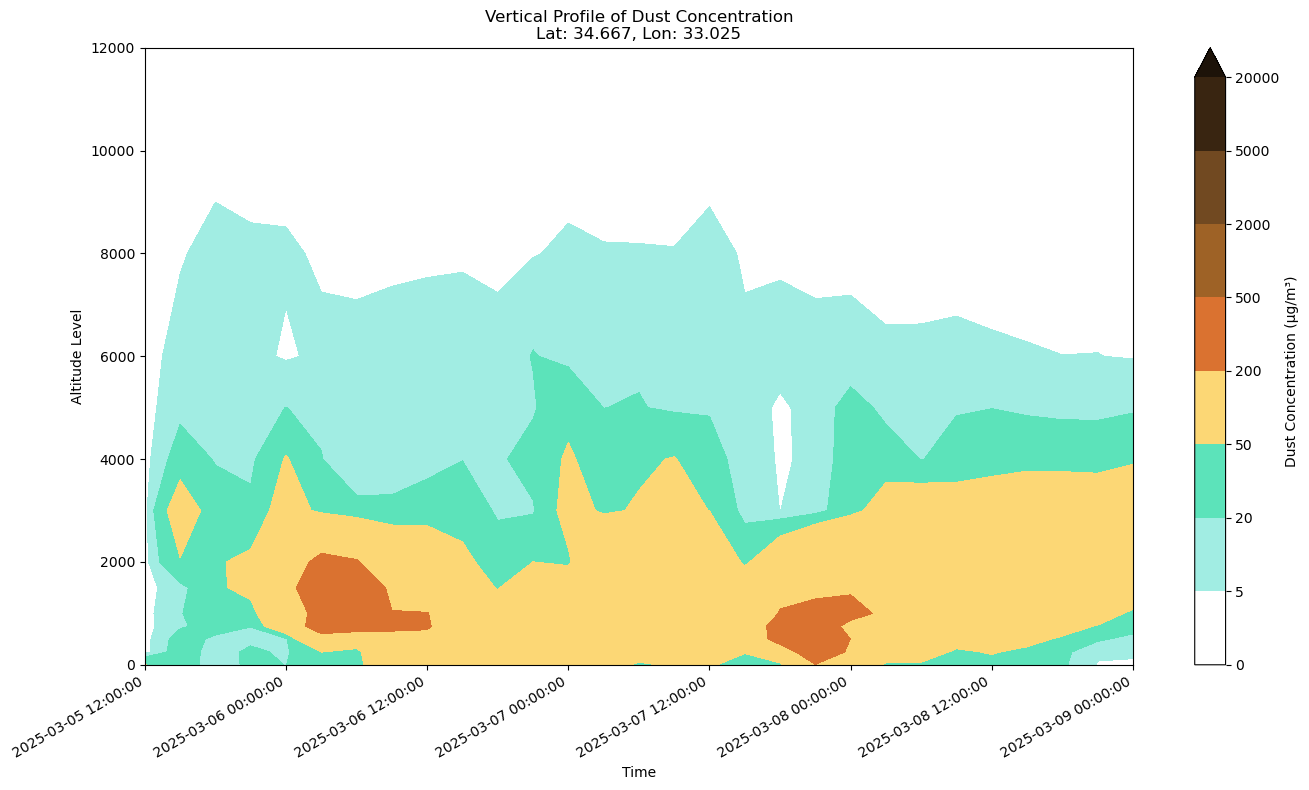

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

# Set contourf
contour = ax.contourf(
    time,
    lev,
    point.T,   # Transpose the point to align axes: (lev, time)
    levels=levels,
    cmap=cmap_bdrc,
    norm=concdu_norm,
    extend='max'
)

# Add colorbar
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Dust Concentration (µg/m³)", extend='max')

# Labels and title
ax.set_title(f"Vertical Profile of Dust Concentration\nLat: {lat}, Lon: {lon}")
ax.set_xlabel("Time")
ax.set_ylabel("Altitude Level")

# Format time axis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
plt.gcf().autofmt_xdate()


# Show plot
plt.tight_layout()
plt.show()

## References and further reading

- Matplotlib `.pyplot.contourf` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html)
- Pandas `.to_datetime` [documentation](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT2-3-interactive_plotting.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT2-5-cross_section.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>